# Лабораторная работа №1
## Обработка признаков (часть 1)

**Дисциплина:** Обработка признаков

**Студент:** Пац И.Н.

**Группа:** ИУ5-23М

**Дата:** 03.05.2026

---

## Описание задания

**Цель работы:** Изучение продвинутых способов предварительной обработки данных для дальнейшего формирования моделей.

**Задачи:**
1. Устранение пропусков в данных
2. Кодирование категориальных признаков
3. Нормализация числовых признаков

**Используемые наборы данных:**
1. **Auto Imports (UCI)** — характеристики автомобилей (205 записей, 26 признаков). Содержит пропуски в числовых признаках (normalized-losses, bore, stroke, horsepower, peak-rpm, price). Категориальные признаки: make, fuel-type, body-style, drive-wheels и др.
2. **Auto MPG (UCI)** — расход топлива автомобилей (398 записей, 9 признаков). Содержит пропуски в horsepower. Категориальные признаки: origin, car-name.
3. **California Housing** — цены на жилье в Калифорнии (20640 записей, 10 признаков). Содержит пропуски в total_bedrooms. Категориальный признак: ocean_proximity.

---
## 1. Загрузка и первичный анализ данных

In [25]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.impute import SimpleImputer, MissingIndicator, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder,
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('Библиотеки успешно загружены')

Библиотеки успешно загружены


### 1.1. Датасет Auto Imports (UCI)

Набор данных содержит технические характеристики и цены на автомобили. Имеет пропуски, категориальные и числовые признаки.

In [26]:
# Загрузка данных Auto Imports
auto_cols = [
    'symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
    'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
    'wheel-base', 'length', 'width', 'height', 'curb-weight',
    'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system',
    'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm',
    'city-mpg', 'highway-mpg', 'price'
]
autos = pd.read_csv('autos.csv', header=None, names=auto_cols, na_values='?')
print(f'Размер датасета Auto Imports: {autos.shape}')
print(f'Количество записей: {len(autos)}')
print(f'Количество признаков: {len(autos.columns)}')
autos.head(10)

Размер датасета Auto Imports: (205, 26)
Количество записей: 205
Количество признаков: 26


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250.0
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710.0
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,18920.0
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875.0
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160.0,5500.0,16,22,NaN


In [27]:
# Информация о типах данных и пропусках
print('Информация о датасете Auto Imports:')
autos.info()

Информация о датасете Auto Imports:
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  e

In [28]:
# Статистика по числовым признакам
autos.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [29]:
# Анализ пропусков
missing_autos = pd.DataFrame({
    'Количество пропусков': autos.isnull().sum(),
    'Процент пропусков': (autos.isnull().sum() / len(autos) * 100).round(2)
})
missing_autos[missing_autos['Количество пропусков'] > 0].sort_values('Процент пропусков', ascending=False)

,Количество пропусков,Процент пропусков
normalized-losses,41,20.00
bore,4,1.95
stroke,4,1.95
price,4,1.95
num-of-doors,2,0.98
horsepower,2,0.98
peak-rpm,2,0.98


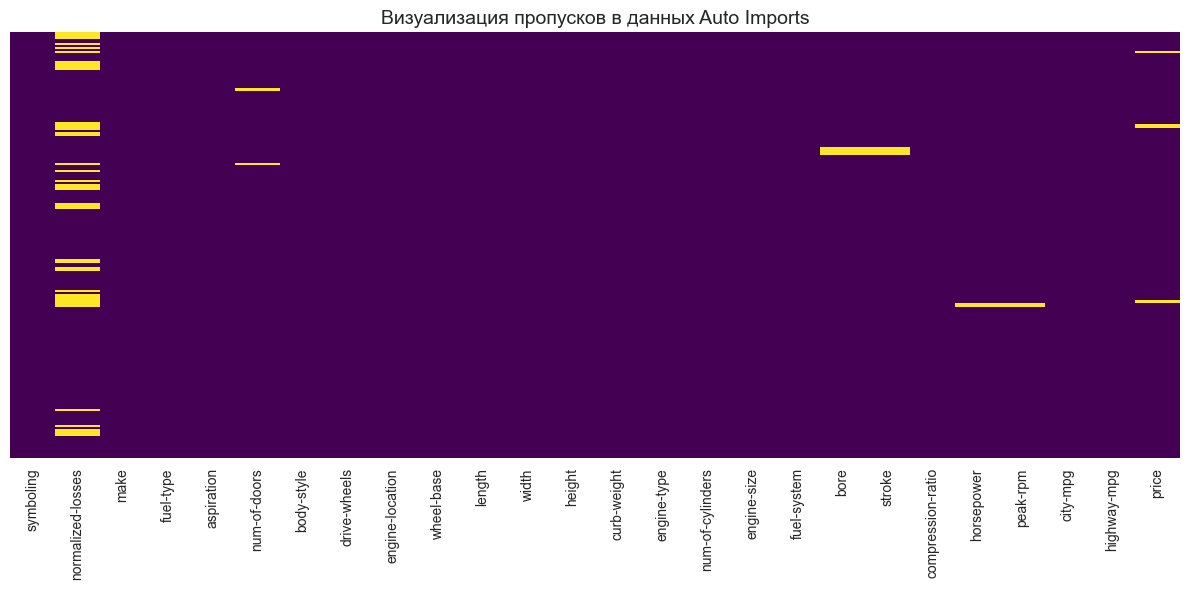

In [30]:
# Визуализация пропусков
plt.figure(figsize=(12, 6))
sns.heatmap(autos.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Визуализация пропусков в данных Auto Imports', fontsize=14)
plt.tight_layout()
plt.show()

### 1.2. Датасет Auto MPG (UCI)

Набор данных содержит информацию о расходе топлива различных автомобилей.

In [31]:
# Загрузка данных Auto MPG
mpg_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
            'acceleration', 'model-year', 'origin', 'car-name']
mpg = pd.read_csv('auto_mpg.csv', sep=r'\s+', header=None, names=mpg_cols, na_values='?')
print(f'Размер датасета Auto MPG: {mpg.shape}')
print(f'Количество записей: {len(mpg)}')
print(f'Количество признаков: {len(mpg.columns)}')
mpg.head(10)

Размер датасета Auto MPG: (398, 9)
Количество записей: 398
Количество признаков: 9


,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year,origin,car-name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
5,15.0,8,429.0,198.0,4341.0,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220.0,4354.0,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215.0,4312.0,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225.0,4425.0,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190.0,3850.0,8.5,70,1,amc ambassador dpl


In [32]:
# Информация о данных
print('Информация о датасете Auto MPG:')
mpg.info()

Информация о датасете Auto MPG:
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model-year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car-name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [33]:
# Анализ пропусков
missing_mpg = pd.DataFrame({
    'Количество пропусков': mpg.isnull().sum(),
    'Процент пропусков': (mpg.isnull().sum() / len(mpg) * 100).round(2)
})
missing_mpg[missing_mpg['Количество пропусков'] > 0]

,Количество пропусков,Процент пропусков
horsepower,6,1.51


### 1.3. Датасет California Housing

Набор данных содержит информацию о ценах на жилье в различных районах Калифорнии.

In [34]:
# Загрузка данных California Housing
housing = pd.read_csv('house_prices.csv')
print(f'Размер датасета California Housing: {housing.shape}')
print(f'Количество записей: {len(housing)}')
print(f'Количество признаков: {len(housing.columns)}')
housing.head(10)

Размер датасета California Housing: (20640, 10)
Количество записей: 20640
Количество признаков: 10


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [35]:
# Информация о данных
print('Информация о датасете California Housing:')
housing.info()

Информация о датасете California Housing:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [36]:
# Анализ пропусков
missing_housing = pd.DataFrame({
    'Количество пропусков': housing.isnull().sum(),
    'Процент пропусков': (housing.isnull().sum() / len(housing) * 100).round(2)
})
missing_housing[missing_housing['Количество пропусков'] > 0]

,Количество пропусков,Процент пропусков
total_bedrooms,207,1.0


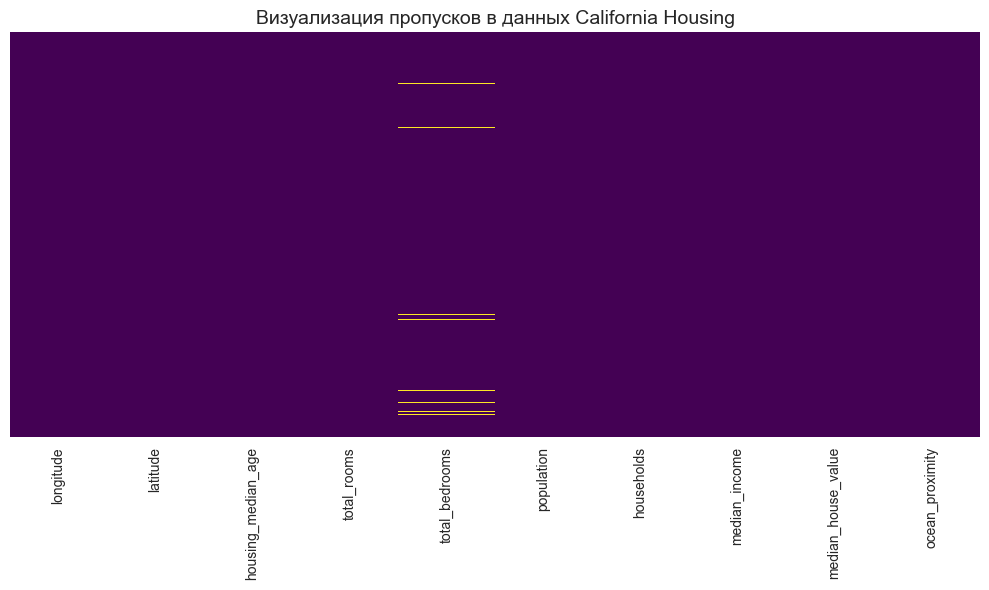

In [37]:
# Визуализация пропусков в Housing
plt.figure(figsize=(10, 6))
sns.heatmap(housing.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Визуализация пропусков в данных California Housing', fontsize=14)
plt.tight_layout()
plt.show()

---
## 2. Устранение пропусков в данных

### 2.1. Обработка пропусков в Auto Imports

В датасете Auto Imports пропуски есть в признаках:
- **normalized-losses** — 41 пропуск (20.0%)
- **bore** — 4 пропуска (2.0%)
- **stroke** — 4 пропуска (2.0%)
- **horsepower** — 2 пропуска (1.0%)
- **peak-rpm** — 2 пропуска (1.0%)
- **price** — 4 пропуска (2.0%)

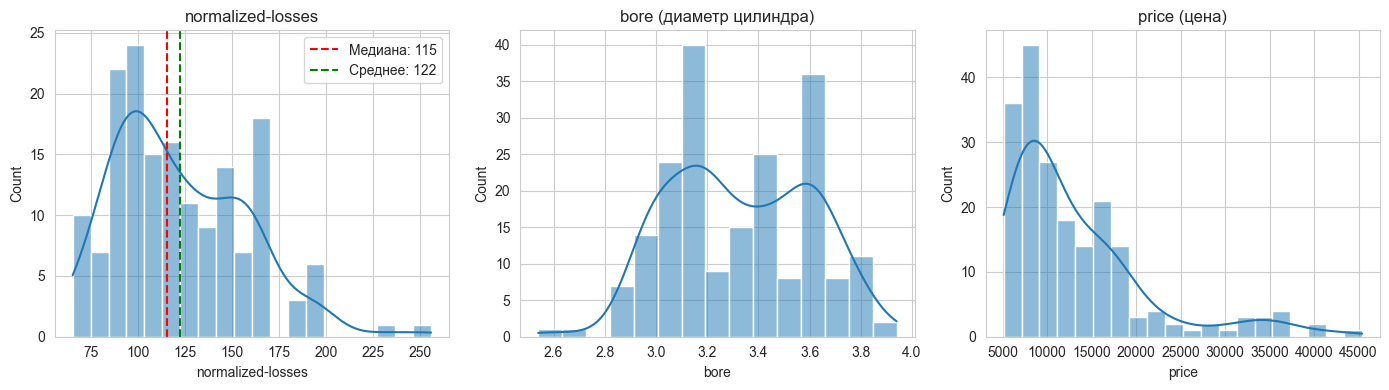

In [38]:
# Создадим копию для работы
autos_clean = autos.copy()

# Проанализируем распределение normalized-losses
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.histplot(autos_clean['normalized-losses'].dropna(), bins=20, kde=True)
plt.axvline(autos_clean['normalized-losses'].median(), color='red', linestyle='--',
            label=f'Медиана: {autos_clean["normalized-losses"].median():.0f}')
plt.axvline(autos_clean['normalized-losses'].mean(), color='green', linestyle='--',
            label=f'Среднее: {autos_clean["normalized-losses"].mean():.0f}')
plt.title('normalized-losses', fontsize=12)
plt.legend()

plt.subplot(1, 3, 2)
sns.histplot(autos_clean['bore'].dropna(), bins=15, kde=True)
plt.title('bore (диаметр цилиндра)', fontsize=12)

plt.subplot(1, 3, 3)
sns.histplot(autos_clean['price'].dropna(), bins=20, kde=True)
plt.title('price (цена)', fontsize=12)

plt.tight_layout()
plt.show()

In [39]:
# Заполнение пропусков в числовых признаках медианой
numeric_cols_na = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_cols_na:
    autos_clean[col + '_filled'] = autos_clean[col].fillna(autos_clean[col].median())

print('Результаты заполнения пропусков:')
for col in numeric_cols_na:
    print(f'{col}: {autos_clean[col].isnull().sum()} -> {autos_clean[col + "_filled"].isnull().sum()}')

Результаты заполнения пропусков:
normalized-losses: 41 -> 0
bore: 4 -> 0
stroke: 4 -> 0
horsepower: 2 -> 0
peak-rpm: 2 -> 0
price: 4 -> 0


In [40]:
# Сравнение статистик до и после
print('Сравнение статистик до/после заполнения:')
comparison = pd.DataFrame({
    'Исходная_медиана': [autos[col].median() for col in numeric_cols_na],
    'После_медиана': [autos_clean[col + '_filled'].median() for col in numeric_cols_na],
    'Исходное_среднее': [autos[col].mean() for col in numeric_cols_na],
    'После_среднее': [autos_clean[col + '_filled'].mean() for col in numeric_cols_na],
}, index=numeric_cols_na)
print(comparison.round(2))

Сравнение статистик до/после заполнения:
                   Исходная_медиана  После_медиана  Исходное_среднее  \
normalized-losses            115.00         115.00            122.00   
bore                           3.31           3.31              3.33   
stroke                         3.29           3.29              3.26   
horsepower                    95.00          95.00            104.26   
peak-rpm                    5200.00        5200.00           5125.37   
price                      10295.00       10295.00          13207.13   

                   После_среднее  
normalized-losses         120.60  
bore                        3.33  
stroke                      3.26  
horsepower                104.17  
peak-rpm                 5126.10  
price                   13150.31  


### 2.2. Обработка пропусков в Auto MPG

Пропуски в horsepower:
      mpg  cylinders  displacement  horsepower  weight  acceleration  \
32   25.0          4          98.0         NaN  2046.0          19.0   
126  21.0          6         200.0         NaN  2875.0          17.0   
330  40.9          4          85.0         NaN  1835.0          17.3   
336  23.6          4         140.0         NaN  2905.0          14.3   
354  34.5          4         100.0         NaN  2320.0          15.8   
374  23.0          4         151.0         NaN  3035.0          20.5   

     model-year  origin              car-name  
32           71       1            ford pinto  
126          74       1         ford maverick  
330          80       2  renault lecar deluxe  
336          80       1    ford mustang cobra  
354          81       2           renault 18i  
374          82       1        amc concord dl  



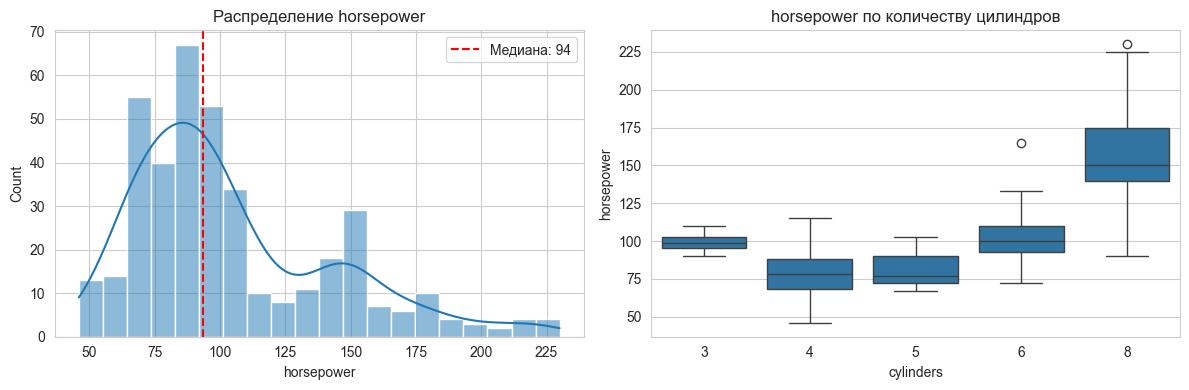

In [41]:
# Анализ пропусков в horsepower
print('Пропуски в horsepower:')
print(mpg[mpg['horsepower'].isnull()])
print()

# Визуализация распределения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(mpg['horsepower'].dropna(), bins=20, kde=True)
plt.axvline(mpg['horsepower'].median(), color='red', linestyle='--',
            label=f'Медиана: {mpg["horsepower"].median():.0f}')
plt.title('Распределение horsepower', fontsize=12)
plt.legend()

plt.subplot(1, 2, 2)
# Зависимость horsepower от cylinders
mpg_box = mpg.dropna(subset=['horsepower'])
sns.boxplot(x='cylinders', y='horsepower', data=mpg_box)
plt.title('horsepower по количеству цилиндров', fontsize=12)
plt.tight_layout()
plt.show()

In [42]:
# Метод 1: Заполнение медианой
mpg_clean = mpg.copy()
hp_median = mpg_clean['horsepower'].median()
mpg_clean['horsepower_median'] = mpg_clean['horsepower'].fillna(hp_median)

# Метод 2: Заполнение по группе (cylinders)
mpg_clean['horsepower_by_cyl'] = mpg_clean.groupby('cylinders')['horsepower'].transform(
    lambda x: x.fillna(x.median())
)

print(f'Медиана общего horsepower: {hp_median:.0f}')
print()
print('Медианы horsepower по группам cylinders:')
print(mpg_clean.groupby('cylinders')['horsepower'].median())
print()
print('Сравнение методов:')
print(f'Пропусков после медианы: {mpg_clean["horsepower_median"].isnull().sum()}')
print(f'Пропусков после группировки: {mpg_clean["horsepower_by_cyl"].isnull().sum()}')

Медиана общего horsepower: 94

Медианы horsepower по группам cylinders:
cylinders
3     98.5
4     78.0
5     77.0
6    100.0
8    150.0
Name: horsepower, dtype: float64

Сравнение методов:
Пропусков после медианы: 0
Пропусков после группировки: 0


### 2.3. Обработка пропусков в California Housing

Пропуски в total_bedrooms:
Количество: 207
Процент: 1.0%



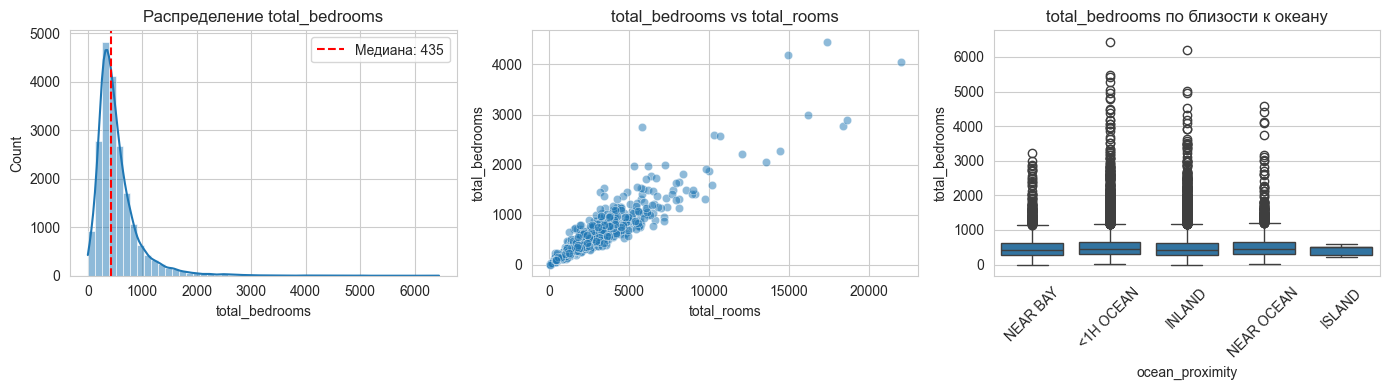

In [43]:
# Анализ пропусков в total_bedrooms
print('Пропуски в total_bedrooms:')
print(f'Количество: {housing["total_bedrooms"].isnull().sum()}')
print(f'Процент: {(housing["total_bedrooms"].isnull().sum() / len(housing) * 100).round(2)}%')
print()

# Визуализация
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.histplot(housing['total_bedrooms'].dropna(), bins=50, kde=True)
plt.axvline(housing['total_bedrooms'].median(), color='red', linestyle='--',
            label=f'Медиана: {housing["total_bedrooms"].median():.0f}')
plt.title('Распределение total_bedrooms', fontsize=12)
plt.legend()

plt.subplot(1, 3, 2)
sns.scatterplot(x='total_rooms', y='total_bedrooms', data=housing.sample(1000), alpha=0.5)
plt.title('total_bedrooms vs total_rooms', fontsize=12)

plt.subplot(1, 3, 3)
sns.boxplot(x='ocean_proximity', y='total_bedrooms', data=housing.dropna(subset=['total_bedrooms']))
plt.title('total_bedrooms по близости к океану', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Заполнение пропусков с использованием sklearn SimpleImputer
housing_clean = housing.copy()

# Метод 1: Медиана
imputer_median = SimpleImputer(strategy='median')
housing_clean['total_bedrooms_median'] = imputer_median.fit_transform(
    housing_clean[['total_bedrooms']]
)

# Метод 2: Среднее
imputer_mean = SimpleImputer(strategy='mean')
housing_clean['total_bedrooms_mean'] = imputer_mean.fit_transform(
    housing_clean[['total_bedrooms']]
)

print('Сравнение методов:')
print(f'Исходных пропусков: {housing_clean["total_bedrooms"].isnull().sum()}')
print(f'После median: {housing_clean["total_bedrooms_median"].isnull().sum()}')
print(f'После mean: {housing_clean["total_bedrooms_mean"].isnull().sum()}')
print()
print(f'Медиана: {housing["total_bedrooms"].median():.2f}')
print(f'Среднее: {housing["total_bedrooms"].mean():.2f}')

Сравнение методов:
Исходных пропусков: 207
После median: 0
После mean: 0

Медиана: 435.00
Среднее: 537.87


In [45]:
# Демонстрация KNNImputer на данных Housing
from sklearn.impute import KNNImputer

# Выберем числовые признаки для KNN
housing_knn_data = housing[['total_rooms', 'total_bedrooms', 'population', 'households',
                             'median_income', 'housing_median_age']].copy()

knn_imputer = KNNImputer(n_neighbors=5)
housing_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(housing_knn_data),
    columns=housing_knn_data.columns
)

print('Сравнение статистик total_bedrooms:')
print(f'Исходная медиана: {housing["total_bedrooms"].median():.2f}')
print(f'Медиана после KNN: {housing_knn_imputed["total_bedrooms"].median():.2f}')
print(f'Исходное среднее: {housing["total_bedrooms"].mean():.2f}')
print(f'Среднее после KNN: {housing_knn_imputed["total_bedrooms"].mean():.2f}')

Сравнение статистик total_bedrooms:
Исходная медиана: 435.00
Медиана после KNN: 435.00
Исходное среднее: 537.87
Среднее после KNN: 537.84


### 2.4. Использование MissingIndicator (из лекций)

Метод `MissingIndicator` создаёт бинарную маску пропусков — сам факт пропуска может быть информативен. В лекциях используется совместно с `SimpleImputer`.

In [46]:
def impute_column(dataset, column, strategy_param, fill_value_param=None):
    """Заполнение пропусков с MissingIndicator + SimpleImputer"""
    temp_data = dataset[[column]].values
    size = temp_data.shape[0]
    indicator = MissingIndicator()
    mask = indicator.fit_transform(temp_data)
    imputer = SimpleImputer(strategy=strategy_param, fill_value=fill_value_param)
    all_data = imputer.fit_transform(temp_data)
    return all_data.reshape((size,)), all_data[mask], temp_data[mask]

# Применение к total_bedrooms
filled, filled_vals, missed_vals = impute_column(housing, 'total_bedrooms', 'median')
print(f'Всего записей: {len(filled)}')
print(f'Было пропусков: {len(missed_vals)}')
print(f'Заполненные значения (первые 5): {filled_vals[:5].flatten()}')

Всего записей: 20640
Было пропусков: 207
Заполненные значения (первые 5): [435. 435. 435. 435. 435.]


### 2.5. Pipeline + GridSearchCV для KNNImputer (из лекций)

В лекциях `KNNImputer` используется в `Pipeline` с `StandardScaler` и `Lasso`, а `GridSearchCV` подбирает оптимальное `n_neighbors`.

In [47]:
pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5, weights='distance', add_indicator=False)),
    ('scaler', StandardScaler()),
    ('regressor', Lasso(max_iter=2000)),
])

y_housing = housing['median_house_value'].values
param_grid = {'imputer__n_neighbors': [3, 5, 7, 10]}

grid_search = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1, scoring='r2')
print('Подбор n_neighbors для KNNImputer...')
grid_search.fit(housing_knn_data, y_housing)
print(f'Лучшее n_neighbors: {grid_search.best_params_["imputer__n_neighbors"]}')
print(f'Лучшая R^2: {grid_search.best_score_:.4f}')

Подбор n_neighbors для KNNImputer...
Лучшее n_neighbors: 5
Лучшая R^2: 0.5529


### 2.6. IterativeImputer (MissForest) из лекций

Метод **MICE (Multivariate Imputation by Chained Equations)** с использованием случайного леса (**MissForest**).

In [48]:
imputer_missForest = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=0),
    max_iter=10, random_state=0
)
housing_missforest = pd.DataFrame(
    imputer_missForest.fit_transform(housing_knn_data),
    columns=housing_knn_data.columns
)

print('Сравнение total_bedrooms после MissForest:')
print(f'Исходная медиана: {housing["total_bedrooms"].median():.2f}')
print(f'Медиана после MissForest: {housing_missforest["total_bedrooms"].median():.2f}')
print(f'Исходное среднее: {housing["total_bedrooms"].mean():.2f}')
print(f'Среднее после MissForest: {housing_missforest["total_bedrooms"].mean():.2f}')

Сравнение total_bedrooms после MissForest:
Исходная медиана: 435.00
Медиана после MissForest: 435.00
Исходное среднее: 537.87
Среднее после MissForest: 537.92


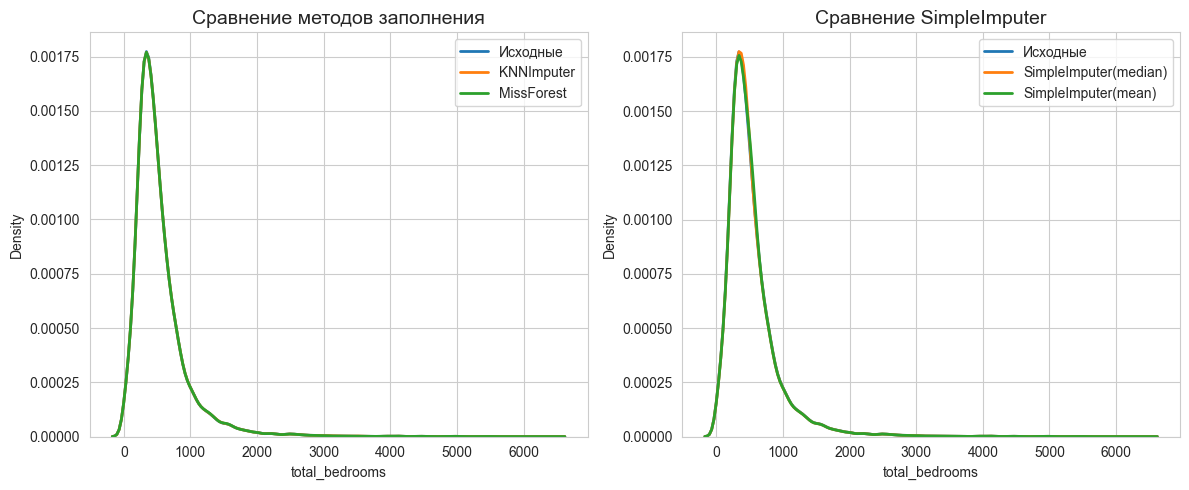

In [49]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(housing['total_bedrooms'].dropna(), label='Исходные', linewidth=2)
sns.kdeplot(housing_knn_imputed['total_bedrooms'], label='KNNImputer', linewidth=2)
sns.kdeplot(housing_missforest['total_bedrooms'], label='MissForest', linewidth=2)
plt.title('Сравнение методов заполнения', fontsize=14)
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(housing['total_bedrooms'].dropna(), label='Исходные', linewidth=2)
sns.kdeplot(housing_clean['total_bedrooms_median'], label='SimpleImputer(median)', linewidth=2)
sns.kdeplot(housing_clean['total_bedrooms_mean'], label='SimpleImputer(mean)', linewidth=2)
plt.title('Сравнение SimpleImputer', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

### Выводы по устранению пропусков

| Метод | Описание | Пример применения |
|-------|----------|-------------------|
| Медиана | Заполнение медианным значением | normalized-losses, bore, price (Auto Imports) |
| Среднее | Заполнение средним значением | total_bedrooms (Housing) |
| По группе | Заполнение на основе группировки | horsepower по cylinders (Auto MPG) |
| SimpleImputer | Универсальный imputer из sklearn | total_bedrooms (Housing) |
| MissingIndicator | Бинарная маска пропусков + SimpleImputer | total_bedrooms (Housing) |
| KNNImputer | Заполнение на основе k ближайших соседей | total_bedrooms (Housing) |
| Pipeline + GridSearchCV | Подбор параметров KNNImputer | total_bedrooms (Housing) |
| IterativeImputer (MissForest) | MICE с RandomForest | total_bedrooms (Housing) |

---
## 3. Кодирование категориальных признаков

### 3.1. Label Encoding (порядковое кодирование)

In [50]:
# Label Encoding для категориальных признаков Auto Imports
le = LabelEncoder()

# Кодирование make (марка автомобиля)
autos_clean['make_label'] = le.fit_transform(autos_clean['make'])
print('Label Encoding для make (первые 10 марок):')
print(autos_clean[['make', 'make_label']].drop_duplicates().sort_values('make_label').head(10))
print()

# Кодирование fuel-type
autos_clean['fuel_type_label'] = le.fit_transform(autos_clean['fuel-type'])
print('Label Encoding для fuel-type:')
print(autos_clean[['fuel-type', 'fuel_type_label']].drop_duplicates().sort_values('fuel_type_label'))

Label Encoding для make (первые 10 марок):
             make  make_label
0     alfa-romero           0
3            audi           1
10            bmw           2
18      chevrolet           3
21          dodge           4
30          honda           5
43          isuzu           6
47         jaguar           7
50          mazda           8
67  mercedes-benz           9

Label Encoding для fuel-type:
   fuel-type  fuel_type_label
63    diesel                0
0        gas                1


In [51]:
# Label Encoding для origin в Auto MPG
mpg_clean['origin_label'] = le.fit_transform(mpg_clean['origin'].astype(str))
print('Label Encoding для origin:')
print(mpg_clean[['origin', 'origin_label']].drop_duplicates().sort_values('origin_label'))

Label Encoding для origin:
    origin  origin_label
0        1             0
19       2             1
14       3             2


### 3.2. One-Hot Encoding (прямое кодирование)

In [52]:
# One-Hot Encoding для body-style в Auto Imports
autos_ohe = pd.get_dummies(autos_clean, columns=['body-style'], prefix='body')
print('One-Hot Encoding для body-style (первые 5 строк):')
body_cols = [c for c in autos_ohe.columns if c.startswith('body_')]
print(pd.concat([autos_clean[['body-style']], autos_ohe[body_cols]], axis=1).drop_duplicates().head(10))

One-Hot Encoding для body-style (первые 5 строк):
     body-style  body_convertible  body_hardtop  body_hatchback  body_sedan  \
0   convertible              True         False           False       False   
2     hatchback             False         False            True       False   
3         sedan             False         False           False        True   
7         wagon             False         False           False       False   
69      hardtop             False          True           False       False   

    body_wagon  
0        False  
2        False  
3        False  
7         True  
69       False  


In [53]:
# One-Hot Encoding с помощью sklearn для ocean_proximity
ohe = OneHotEncoder(sparse_output=False)
housing_ohe = ohe.fit_transform(housing_clean[['ocean_proximity']])

print('One-Hot Encoding для ocean_proximity:')
print(f'Категории: {ohe.categories_}')
print(f'Форма после OHE: {housing_ohe.shape}')
print()
ohe_df = pd.DataFrame(housing_ohe, columns=ohe.get_feature_names_out(['ocean_proximity']))
print(pd.concat([housing_clean[['ocean_proximity']].head(), ohe_df.head()], axis=1))

One-Hot Encoding для ocean_proximity:
Категории: [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]
Форма после OHE: (20640, 5)

  ocean_proximity  ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  \
0        NEAR BAY                        0.0                     0.0   
1        NEAR BAY                        0.0                     0.0   
2        NEAR BAY                        0.0                     0.0   
3        NEAR BAY                        0.0                     0.0   
4        NEAR BAY                        0.0                     0.0   

   ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                     0.0                       1.0   
1                     0.0                       1.0   
2                     0.0                       1.0   
3                     0.0                       1.0   
4                     0.0                       1.0   

   ocean_proximity_NEAR OCEAN  
0                         0.0  
1    

In [54]:
# One-Hot Encoding для fuel-type и aspiration
cat_features = ['fuel-type', 'aspiration', 'num-of-doors', 'drive-wheels']
ohe_multi = OneHotEncoder(sparse_output=False, drop='first')
autos_ohe_multi = ohe_multi.fit_transform(autos_clean[cat_features])

print('One-Hot Encoding для нескольких признаков Auto Imports:')
print(f'Категории: {ohe_multi.categories_}')
print(f'Форма после OHE: {autos_ohe_multi.shape}')
print()
ohe_multi_df = pd.DataFrame(autos_ohe_multi, columns=ohe_multi.get_feature_names_out(cat_features))
print(ohe_multi_df.head(10))

One-Hot Encoding для нескольких признаков Auto Imports:
Категории: [array(['diesel', 'gas'], dtype=object), array(['std', 'turbo'], dtype=object), array(['four', 'two', nan], dtype=object), array(['4wd', 'fwd', 'rwd'], dtype=object)]
Форма после OHE: (205, 6)

   fuel-type_gas  aspiration_turbo  num-of-doors_two  num-of-doors_nan  \
0            1.0               0.0               1.0               0.0   
1            1.0               0.0               1.0               0.0   
2            1.0               0.0               1.0               0.0   
3            1.0               0.0               0.0               0.0   
4            1.0               0.0               0.0               0.0   
5            1.0               0.0               1.0               0.0   
6            1.0               0.0               0.0               0.0   
7            1.0               0.0               0.0               0.0   
8            1.0               1.0               0.0               0.0   

### 3.3. Ordinal Encoding (порядковое кодирование с заданным порядком)

In [55]:
# Ordinal Encoding для num-of-cylinders (естественный порядок)
cyl_order = [['two', 'three', 'four', 'five', 'six', 'eight', 'twelve']]
ordinal_enc = OrdinalEncoder(categories=cyl_order)
autos_clean['cylinders_ordinal'] = ordinal_enc.fit_transform(autos_clean[['num-of-cylinders']])

print('Ordinal Encoding для num-of-cylinders:')
print(autos_clean[['num-of-cylinders', 'cylinders_ordinal']].drop_duplicates().sort_values('cylinders_ordinal'))

Ordinal Encoding для num-of-cylinders:
   num-of-cylinders  cylinders_ordinal
55              two                0.0
18            three                1.0
0              four                2.0
4              five                3.0
2               six                4.0
71            eight                5.0
49           twelve                6.0


### 3.4. Использование библиотеки Category Encoders (из лекций)

Библиотека [Category Encoders](https://contrib.scikit-learn.org/category_encoders/) предоставляет дополнительные методы кодирования: CountEncoder (частотное), TargetEncoder (среднее по целевой переменной) и др.

In [56]:
try:
    import category_encoders as ce
    print(f'category_encoders {ce.__version__} уже установлена')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'category_encoders'])
    import category_encoders as ce
    print('category_encoders установлена')

category_encoders 2.8.1 уже установлена


In [57]:
from category_encoders.count import CountEncoder as ce_CountEncoder
from category_encoders.target_encoder import TargetEncoder as ce_TargetEncoder

# CountEncoder — частотное кодирование для make
ce_count = ce_CountEncoder()
autos_count = ce_count.fit_transform(autos_clean[['make', 'fuel-type', 'body-style']])
print('CountEncoder (частотное кодирование):')
print(autos_count.head())

# TargetEncoder — среднее целевой для ocean_proximity
ce_target = ce_TargetEncoder()
housing_target = ce_target.fit_transform(
    housing_clean[['ocean_proximity']], housing_clean['median_house_value'])
print('\nTargetEncoder для ocean_proximity:')
print(pd.concat([housing_clean[['ocean_proximity']].head(), housing_target.head()], axis=1))

CountEncoder (частотное кодирование):
   make  fuel-type  body-style
0     3        185           6
1     3        185           6
2     3        185          70
3     7        185          96
4     7        185          96

TargetEncoder для ocean_proximity:
  ocean_proximity  ocean_proximity
0        NEAR BAY     259212.31179
1        NEAR BAY     259212.31179
2        NEAR BAY     259212.31179
3        NEAR BAY     259212.31179
4        NEAR BAY     259212.31179


### Сравнение методов кодирования

| Метод | Описание | Преимущества | Недостатки |
|-------|----------|--------------|------------|
| **Label Encoding** | Целочисленные метки | Простота, память | Подразумевает порядок |
| **One-Hot Encoding** | Бинарные столбцы | Нет порядка, универсально | Много признаков |
| **Ordinal Encoding** | Порядок с заданными категориями | Учитывает порядок | Требует знания порядка |
| **CountEncoder** | Частота категорий | Учитывает популярность | Потеря информации о редких категориях |
| **TargetEncoder** | Среднее целевой переменной | Учитывает связь с целевой | Может привести к переобучению |

---
## 4. Нормализация числовых признаков

### 4.1. Стандартизация (StandardScaler)

Формула: $z = \frac{x - \mu}{\sigma}$

In [58]:
# Выберем числовые признаки из California Housing
housing_num = housing_clean[['median_income', 'housing_median_age', 'total_rooms',
                              'population', 'households', 'median_house_value']].copy()

print('Исходные статистики:')
housing_num.describe()

Исходные статистики:


,median_income,housing_median_age,total_rooms,population,households,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,2635.763081,1425.476744,499.539680,206855.816909
std,1.899822,12.585558,2181.615252,1132.462122,382.329753,115395.615874
min,0.499900,1.000000,2.000000,3.000000,1.000000,14999.000000
25%,2.563400,18.000000,1447.750000,787.000000,280.000000,119600.000000
50%,3.534800,29.000000,2127.000000,1166.000000,409.000000,179700.000000
75%,4.743250,37.000000,3148.000000,1725.000000,605.000000,264725.000000
max,15.000100,52.000000,39320.000000,35682.000000,6082.000000,500001.000000


In [59]:
# StandardScaler
scaler_std = StandardScaler()
housing_standardized = scaler_std.fit_transform(housing_num)
housing_standardized = pd.DataFrame(housing_standardized, columns=housing_num.columns)

print('После StandardScaler (среднее=0, std=1):')
print(housing_standardized.describe().round(4))

После StandardScaler (среднее=0, std=1):
       median_income  housing_median_age  total_rooms  population  households  \
count     20640.0000          20640.0000   20640.0000  20640.0000  20640.0000   
mean          0.0000              0.0000       0.0000     -0.0000      0.0000   
std           1.0000              1.0000       1.0000      1.0000      1.0000   
min          -1.7743             -2.1962      -1.2073     -1.2561     -1.3040   
25%          -0.6881             -0.8454      -0.5446     -0.5638     -0.5742   
50%          -0.1768              0.0286      -0.2332     -0.2291     -0.2368   
75%           0.4593              0.6643       0.2348      0.2645      0.2758   
max           5.8583              1.8562      16.8156     30.2503     14.6015   

       median_house_value  
count          20640.0000  
mean              -0.0000  
std                1.0000  
min               -1.6626  
25%               -0.7562  
50%               -0.2353  
75%                0.5015  
max  

### 4.2. Min-Max Scaling (MinMaxScaler)

Формула: $X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$

In [60]:
# MinMaxScaler
scaler_mm = MinMaxScaler(feature_range=(0, 1))
housing_minmax = scaler_mm.fit_transform(housing_num)
housing_minmax = pd.DataFrame(housing_minmax, columns=housing_num.columns)

print('После MinMaxScaler (диапазон [0, 1]):')
print(housing_minmax.describe().round(4))

После MinMaxScaler (диапазон [0, 1]):
       median_income  housing_median_age  total_rooms  population  households  \
count     20640.0000          20640.0000   20640.0000  20640.0000  20640.0000   
mean          0.2325              0.5420       0.0670      0.0399      0.0820   
std           0.1310              0.2468       0.0555      0.0317      0.0629   
min           0.0000              0.0000       0.0000      0.0000      0.0000   
25%           0.1423              0.3333       0.0368      0.0220      0.0459   
50%           0.2093              0.5490       0.0540      0.0326      0.0671   
75%           0.2926              0.7059       0.0800      0.0483      0.0993   
max           1.0000              1.0000       1.0000      1.0000      1.0000   

       median_house_value  
count          20640.0000  
mean               0.3956  
std                0.2379  
min                0.0000  
25%                0.2157  
50%                0.3396  
75%                0.5149  
max     

### 4.3. Robust Scaling (RobustScaler)

Формула: $X_{robust} = \frac{X - median}{IQR}$

In [61]:
# RobustScaler
scaler_rob = RobustScaler()
housing_robust = scaler_rob.fit_transform(housing_num)
housing_robust = pd.DataFrame(housing_robust, columns=housing_num.columns)

print('После RobustScaler (медиана=0, IQR=1):')
print(housing_robust.describe().round(4))

После RobustScaler (медиана=0, IQR=1):
       median_income  housing_median_age  total_rooms  population  households  \
count     20640.0000          20640.0000   20640.0000  20640.0000  20640.0000   
mean          0.1541             -0.0190       0.2992      0.2766      0.2786   
std           0.8715              0.6624       1.2831      1.2073      1.1764   
min          -1.3923             -1.4737      -1.2498     -1.2399     -1.2554   
25%          -0.4456             -0.5789      -0.3995     -0.4041     -0.3969   
50%           0.0000              0.0000       0.0000      0.0000      0.0000   
75%           0.5544              0.4211       0.6005      0.5959      0.6031   
max           5.2597              1.2105      21.8750     36.7974     17.4554   

       median_house_value  
count          20640.0000  
mean               0.1871  
std                0.7951  
min               -1.1349  
25%               -0.4141  
50%                0.0000  
75%                0.5859  
max    

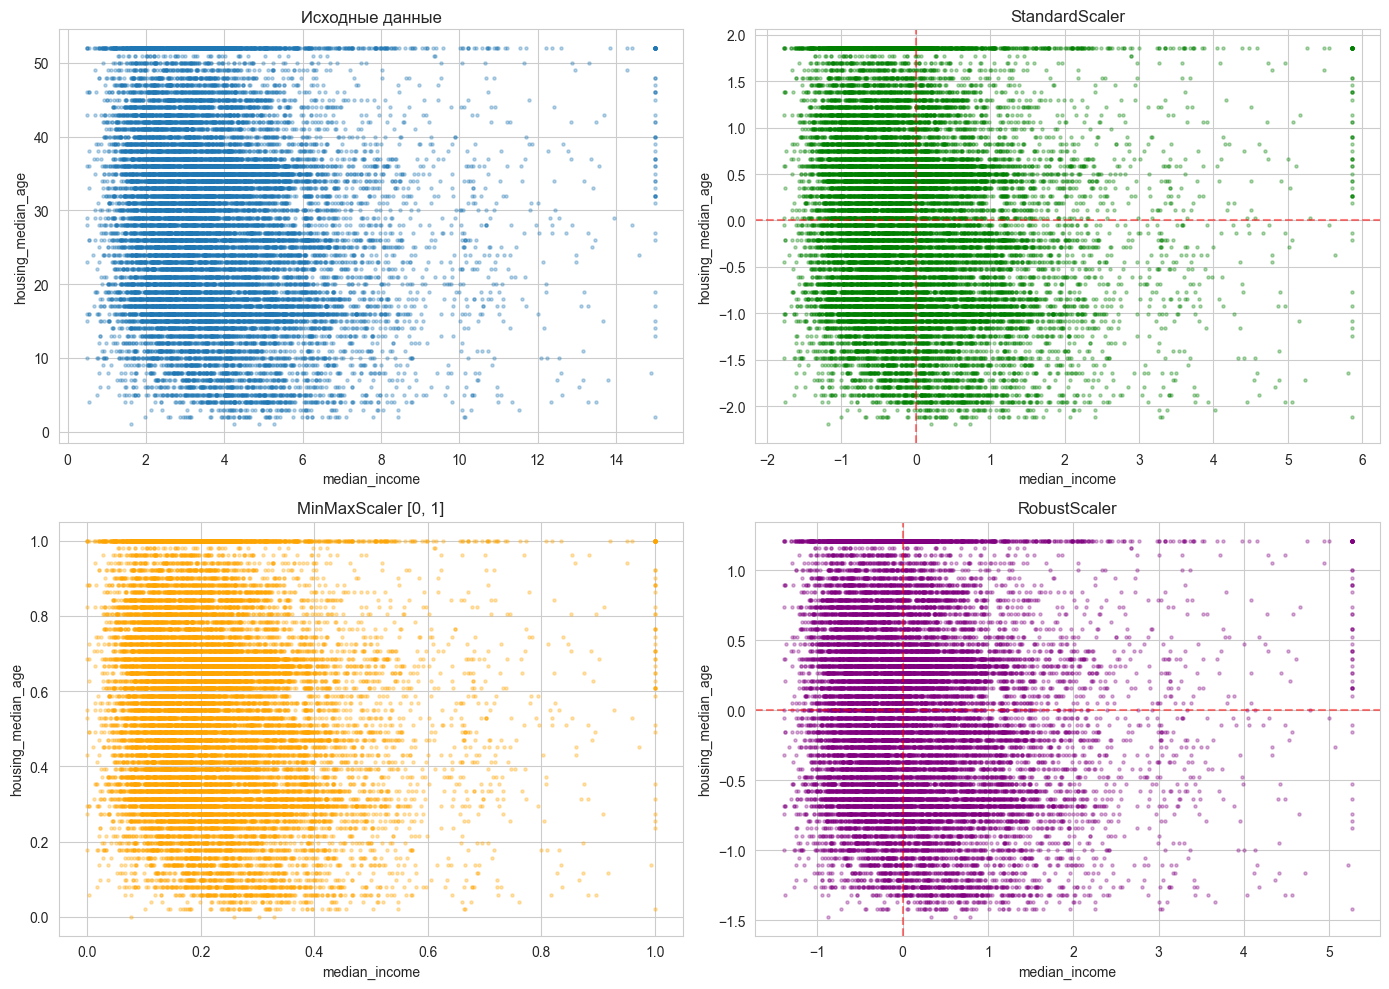

In [62]:
# Визуализация сравнения методов нормализации
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

feature_x, feature_y = 'median_income', 'housing_median_age'

# Исходные данные
axes[0, 0].scatter(housing_num[feature_x], housing_num[feature_y], alpha=0.3, s=5)
axes[0, 0].set_title('Исходные данные', fontsize=12)
axes[0, 0].set_xlabel(feature_x)
axes[0, 0].set_ylabel(feature_y)

# StandardScaler
axes[0, 1].scatter(housing_standardized[feature_x], housing_standardized[feature_y],
                   alpha=0.3, s=5, color='green')
axes[0, 1].set_title('StandardScaler', fontsize=12)
axes[0, 1].set_xlabel(feature_x)
axes[0, 1].set_ylabel(feature_y)
axes[0, 1].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)

# MinMaxScaler
axes[1, 0].scatter(housing_minmax[feature_x], housing_minmax[feature_y],
                   alpha=0.3, s=5, color='orange')
axes[1, 0].set_title('MinMaxScaler [0, 1]', fontsize=12)
axes[1, 0].set_xlabel(feature_x)
axes[1, 0].set_ylabel(feature_y)

# RobustScaler
axes[1, 1].scatter(housing_robust[feature_x], housing_robust[feature_y],
                   alpha=0.3, s=5, color='purple')
axes[1, 1].set_title('RobustScaler', fontsize=12)
axes[1, 1].set_xlabel(feature_x)
axes[1, 1].set_ylabel(feature_y)
axes[1, 1].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

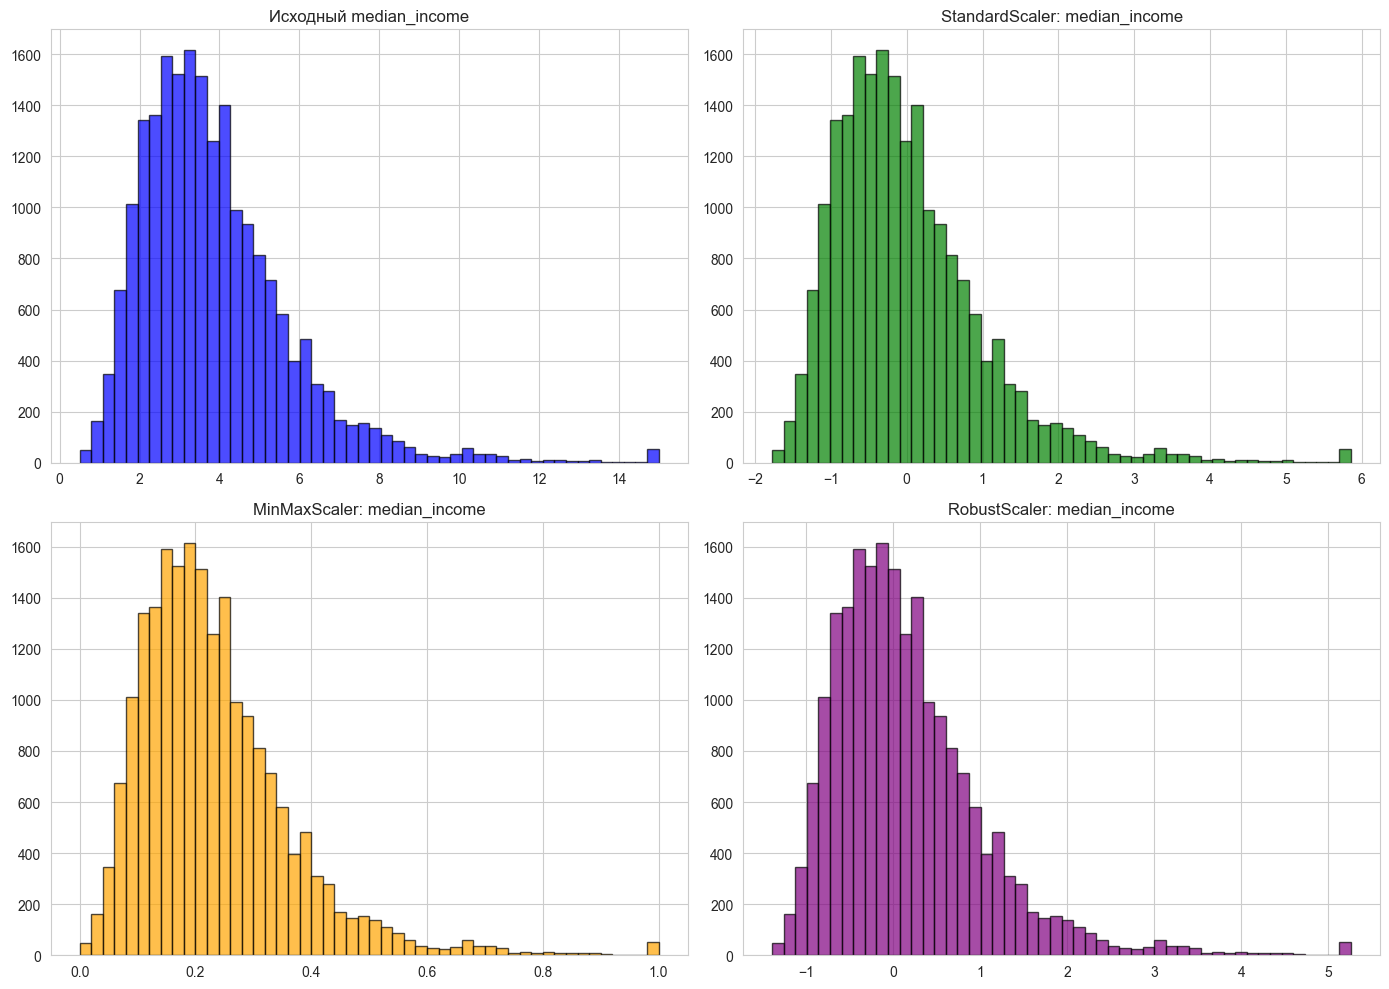

In [63]:
# Сравнение распределений (гистограммы)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

feature = 'median_income'

# Исходные
axes[0, 0].hist(housing_num[feature], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title(f'Исходный {feature}', fontsize=12)

# StandardScaler
axes[0, 1].hist(housing_standardized[feature], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_title(f'StandardScaler: {feature}', fontsize=12)

# MinMaxScaler
axes[1, 0].hist(housing_minmax[feature], bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_title(f'MinMaxScaler: {feature}', fontsize=12)

# RobustScaler
axes[1, 1].hist(housing_robust[feature], bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].set_title(f'RobustScaler: {feature}', fontsize=12)

plt.tight_layout()
plt.show()

In [64]:
# Сводная таблица статистик для сравнения
stats_summary = pd.DataFrame({
    'Исходные': housing_num[feature].describe(),
    'StandardScaler': housing_standardized[feature].describe(),
    'MinMaxScaler': housing_minmax[feature].describe(),
    'RobustScaler': housing_robust[feature].describe()
}).round(4)
print('Сравнение методов нормализации для median_income:')
print(stats_summary)

Сравнение методов нормализации для median_income:
         Исходные  StandardScaler  MinMaxScaler  RobustScaler
count  20640.0000      20640.0000    20640.0000    20640.0000
mean       3.8707          0.0000        0.2325        0.1541
std        1.8998          1.0000        0.1310        0.8715
min        0.4999         -1.7743        0.0000       -1.3923
25%        2.5634         -0.6881        0.1423       -0.4456
50%        3.5348         -0.1768        0.2093        0.0000
75%        4.7432          0.4593        0.2926        0.5544
max       15.0001          5.8583        1.0000        5.2597


### 4.4. MaxAbsScaler (из лекций)

Масштабирует каждый признак на его максимальное абсолютное значение. Сохраняет разреженность данных.

In [65]:
scaler_maxabs = MaxAbsScaler()
housing_maxabs = scaler_maxabs.fit_transform(housing_num)
housing_maxabs = pd.DataFrame(housing_maxabs, columns=housing_num.columns)

print('После MaxAbsScaler (диапазон [-1, 1]):')
print(housing_maxabs.describe().round(4))

После MaxAbsScaler (диапазон [-1, 1]):
       median_income  housing_median_age  total_rooms  population  households  \
count     20640.0000          20640.0000   20640.0000  20640.0000  20640.0000   
mean          0.2580              0.5508       0.0670      0.0399      0.0821   
std           0.1267              0.2420       0.0555      0.0317      0.0629   
min           0.0333              0.0192       0.0001      0.0001      0.0002   
25%           0.1709              0.3462       0.0368      0.0221      0.0460   
50%           0.2357              0.5577       0.0541      0.0327      0.0672   
75%           0.3162              0.7115       0.0801      0.0483      0.0995   
max           1.0000              1.0000       1.0000      1.0000      1.0000   

       median_house_value  
count          20640.0000  
mean               0.4137  
std                0.2308  
min                0.0300  
25%                0.2392  
50%                0.3594  
75%                0.5294  
max    

### 4.5. MeanNormalisation (кастомный класс, из лекций)

Нормализация по формуле: $X_{norm} = \frac{X - mean}{max - min}$

In [66]:
class MeanNormalisation:
    def fit(self, param_df):
        self.means = param_df.mean(axis=0)
        self.ranges = param_df.max(axis=0) - param_df.min(axis=0)
    def transform(self, param_df):
        return (param_df - self.means) / self.ranges
    def fit_transform(self, param_df):
        self.fit(param_df)
        return self.transform(param_df)

mean_norm = MeanNormalisation()
housing_meannorm = mean_norm.fit_transform(housing_num)
print('После MeanNormalisation:')
print(housing_meannorm.describe().round(4))

После MeanNormalisation:
       median_income  housing_median_age  total_rooms  population  households  \
count     20640.0000          20640.0000   20640.0000  20640.0000  20640.0000   
mean          0.0000              0.0000       0.0000     -0.0000      0.0000   
std           0.1310              0.2468       0.0555      0.0317      0.0629   
min          -0.2325             -0.5420      -0.0670     -0.0399     -0.0820   
25%          -0.0902             -0.2086      -0.0302     -0.0179     -0.0361   
50%          -0.0232              0.0071      -0.0129     -0.0073     -0.0149   
75%           0.0602              0.1639       0.0130      0.0084      0.0173   
max           0.7675              0.4580       0.9330      0.9601      0.9180   

       median_house_value  
count          20640.0000  
mean              -0.0000  
std                0.2379  
min               -0.3956  
25%               -0.1799  
50%               -0.0560  
75%                0.1193  
max                0.

### 4.6. Диагностические графики (из лекций)

В лекциях используется функция `diagnostic_plots` с гистограммой и Q-Q plot для оценки нормальности распределения.

Диагностика median_income до нормализации:


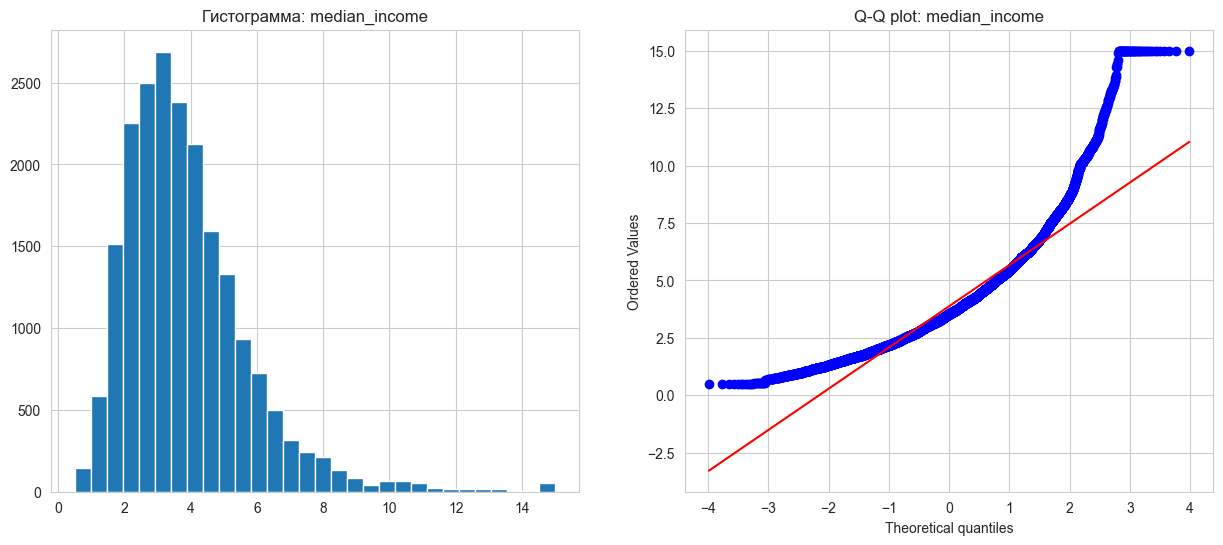

In [67]:
def diagnostic_plots(df, variable):
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    plt.title(f'Гистограмма: {variable}')
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f'Q-Q plot: {variable}')
    plt.show()

print('Диагностика median_income до нормализации:')
diagnostic_plots(housing_num, 'median_income')

Диагностика median_income после StandardScaler:


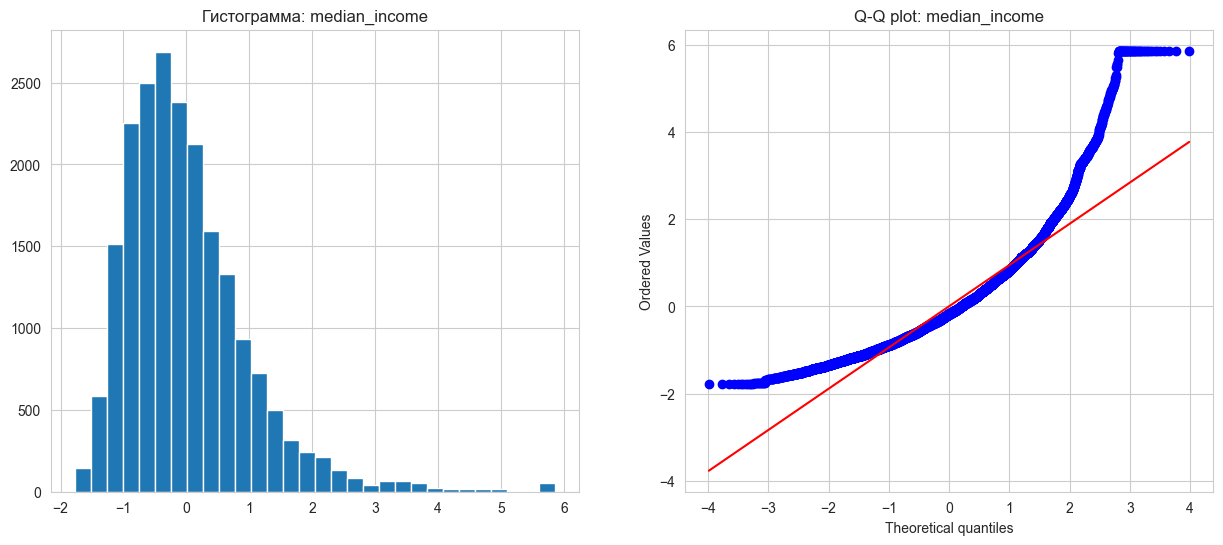

In [68]:
print('Диагностика median_income после StandardScaler:')
diagnostic_plots(housing_standardized, 'median_income')

### Сравнение методов нормализации

| Метод | Описание | Когда использовать |
|-------|----------|-------------------|
| **StandardScaler** | Среднее=0, std=1 | Для алгоритмов, предполагающих нормальное распределение (SVM, линейная регрессия, PCA) |
| **MinMaxScaler** | Диапазон [0, 1] | Когда данные не имеют нормального распределения, для нейронных сетей |
| **RobustScaler** | Медиана=0, IQR=1 | Когда в данных есть выбросы |
| **MaxAbsScaler** | Диапазон [-1, 1] | Для разреженных данных |
| **MeanNormalisation** | (X-mean)/(max-min) | Кастомная нормализация из лекций |

---
## 5. Общие выводы

В ходе лабораторной работы были изучены и применены на практике следующие методы предварительной обработки данных на трех различных наборах данных:

### Устранение пропусков:
- Заполнение **медианой** для числовых признаков с выбросами (normalized-losses, bore, price в Auto Imports)
- Заполнение **средним** для числовых признаков (total_bedrooms в Housing)
- Заполнение **по группе** для учета зависимостей между признаками (horsepower по cylinders в Auto MPG)
- Использование **SimpleImputer** из sklearn для универсального заполнения
- Использование **MissingIndicator** для создания бинарной маски пропусков
- Использование **KNNImputer** для восстановления данных на основе корреляции признаков
- Использование **Pipeline + GridSearchCV** для подбора параметров KNNImputer
- Использование **IterativeImputer (MissForest)** для многомерного восстановления пропусков

### Кодирование категориальных признаков:
- **LabelEncoder** — для преобразования категорий в числовые метки (make, fuel-type, origin)
- **OneHotEncoder** — для создания бинарных признаков без внесения порядка (body-style, ocean_proximity, fuel-type)
- **OrdinalEncoder** — для кодирования с учетом порядка категорий (num-of-cylinders)
- **CountEncoder** — частотное кодирование (make, fuel-type)
- **TargetEncoder** — кодирование средним целевой переменной (ocean_proximity)

### Нормализация числовых признаков:
- **StandardScaler** — стандартизация (центрирование и масштабирование)
- **MinMaxScaler** — приведение к диапазону [0, 1]
- **RobustScaler** — устойчивое масштабирование с использованием медианы и IQR
- **MaxAbsScaler** — масштабирование на максимальное абсолютное значение
- **MeanNormalisation** — кастомная нормализация (X-mean)/(max-min)
- **Диагностические графики** (гистограмма + Q-Q plot) для оценки нормальности распределения

Каждый метод имеет свои преимущества и область применения. Выбор конкретного метода зависит от характера данных, наличия выбросов, требований алгоритма машинного обучения и поставленной задачи.